In [6]:
# %pip install pandas

In [9]:
# %pip install pyarrow


In [1]:
import pandas as pd
df_2024 = pd.read_parquet("../../Data/sort_data/2024_data.parquet")
df_2025 = pd.read_parquet("../../Data/sort_data/2025_data.parquet")
df_2025.head()

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2025-01-09,9,출발시간,ST-2775,ST-462,1,0 days 00:09:00,1379,-12.1,34,27.56414,0.0,0.0
1,2025-01-09,19,출발시간,ST-462,ST-2775,1,0 days 00:10:00,1368,-12.1,30,28.61530,0.0,0.0
2,2025-01-09,16,출발시간,ST-2782,ST-481,1,0 days 00:08:00,1281,-10.0,22,32.87600,0.0,0.0
3,2025-01-09,16,출발시간,ST-2261,ST-3126,1,0 days 00:08:00,1060,-10.0,22,32.87600,0.0,0.0
4,2025-01-09,17,출발시간,ST-32,ST-462,1,0 days 00:48:00,5946,-11.1,25,30.98675,0.0,0.0


In [2]:
df_2024.head()

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,17,출발시간,ST-479,ST-462,2.0,0 days 02:31:00,21873.0,4.3,78,41.94946,0.0,0.0
1,2024-01-01,16,출발시간,ST-460,ST-2425,1.0,0 days 00:11:00,550.0,6.1,65,45.87135,0.0,0.0
2,2024-01-01,16,출발시간,ST-461,ST-2425,1.0,0 days 00:15:00,1582.0,6.1,65,45.87135,0.0,0.0
3,2024-01-01,16,출발시간,ST-479,ST-479,1.0,0 days 00:22:00,2526.0,6.1,65,45.87135,0.0,0.0
4,2024-01-01,17,출발시간,ST-2264,ST-479,1.0,0 days 00:02:00,445.0,4.3,78,41.94946,0.0,0.0


In [5]:
df = df_2024[df_2024.시작_대여소_ID.isin(['ST-1023', 'ST-1024', 'ST-1480'])]

In [7]:
pd.read_csv("../../Data/2024_st_hhj.csv")

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,18,출발시간,ST-1023,ST-476,2.0,0.9,89,35.09499,0.0,0.0
1,2024-01-01,21,출발시간,ST-450,ST-453,1.0,0.3,97,32.96009,0.0,0.0
2,2024-01-01,21,출발시간,ST-450,ST-453,1.0,0.3,97,32.96009,0.0,0.0
3,2024-01-01,17,출발시간,ST-1024,ST-453,1.0,4.3,78,41.94946,0.0,0.0
4,2024-01-01,17,출발시간,ST-1024,ST-453,1.0,4.3,78,41.94946,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
19264,2024-12-31,6,출발시간,ST-450,ST-1483,1.0,-3.5,53,34.04955,0.0,0.0
19265,2024-12-31,8,출발시간,ST-450,ST-2244,1.0,-3.8,52,33.82976,0.0,0.0
19266,2024-12-31,20,출발시간,ST-450,ST-453,1.0,-2.7,64,33.25028,0.0,0.0
19267,2024-12-31,18,출발시간,ST-450,ST-1483,1.0,-1.5,57,36.08755,0.0,0.0


In [ ]:
# %pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.0 MB 11.4 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 11.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 11.0 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --- ------------------------------------ 3.1/36.5 MB 15.8 MB/s eta 0:00:03
   ----- ---------------------------------- 4.7/36.5 MB 10.9 MB/s eta 0:00:03
   -------- ------------------------------- 7.6/36.5 MB 11.9 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/36.5 MB 11.6 MB/s eta 0:00:03
   ------------- -------------------------- 12.1/36.5 MB 11.

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. 파일 읽기
# -----------------------------
df = pd.read_csv("../../Data/2024_st_hhj.csv")

# -----------------------------
# 2. 날짜형 변환
# -----------------------------
df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])

# -----------------------------
# 3. 중복 제거
# -----------------------------
df = df.drop_duplicates().copy()

# -----------------------------
# 4. 시간별 예측용 집계
# 날짜 + 시간대 + 시작 대여소 기준
# -----------------------------
hourly_df = (
    df.groupby(["기준_날짜", "시간대", "시작_대여소_ID"], as_index=False)
      .agg({
          "전체_건수": "sum",
          "온도": "mean",
          "습도": "mean",
          "불쾌지수": "mean",
          "강수량": "mean",
          "적설량": "mean"
      })
      .sort_values(["기준_날짜", "시간대", "시작_대여소_ID"])
      .reset_index(drop=True)
)

# -----------------------------
# 5. 날짜 파생변수 만들기
# -----------------------------
hourly_df["요일"] = hourly_df["기준_날짜"].dt.dayofweek   # 월=0, 일=6
hourly_df["월"] = hourly_df["기준_날짜"].dt.month
hourly_df["주말여부"] = (hourly_df["요일"] >= 5).astype(int)

# -----------------------------
# 6. 시간대 주기형 변환
# -----------------------------
hourly_df["hour_sin"] = np.sin(2 * np.pi * hourly_df["시간대"] / 24)
hourly_df["hour_cos"] = np.cos(2 * np.pi * hourly_df["시간대"] / 24)

# -----------------------------
# 7. 시작 대여소 원-핫 인코딩
# -----------------------------
model_df = pd.get_dummies(hourly_df, columns=["시작_대여소_ID"], drop_first=False)

# -----------------------------
# 8. 연속형 변수 스케일링
# -----------------------------
scale_cols = ["온도", "습도", "불쾌지수", "강수량", "적설량"]

scaler = StandardScaler()
model_df[[f"{col}_scaled" for col in scale_cols]] = scaler.fit_transform(model_df[scale_cols])

# -----------------------------
# 9. 최종 학습용 컬럼 선택
# -----------------------------
feature_cols = [
    "시간대",
    "요일",
    "월",
    "주말여부",
    "hour_sin",
    "hour_cos",
    "온도_scaled",
    "습도_scaled",
    "불쾌지수_scaled",
    "강수량_scaled",
    "적설량_scaled"
] + [col for col in model_df.columns if col.startswith("시작_대여소_ID_")]

train_ready_df = model_df[["기준_날짜", "전체_건수"] + feature_cols].copy()

# -----------------------------
# 10. 저장
# -----------------------------
train_ready_df.to_csv("2024_st_hhj_hourly_scaled.csv", index=False, encoding="utf-8-sig")

print("완료")
print(train_ready_df.head())
print(train_ready_df.shape)

완료
       기준_날짜  전체_건수  시간대  요일  월  주말여부  hour_sin  hour_cos  온도_scaled  \
0 2024-01-01    2.0    2   0  1     0  0.500000  0.866025  -1.767594   
1 2024-01-01    1.0    9   0  1     0  0.707107 -0.707107  -1.655731   
2 2024-01-01    1.0   10   0  1     0  0.500000 -0.866025  -1.381159   
3 2024-01-01    1.0   13   0  1     0 -0.258819 -0.965926  -1.025232   
4 2024-01-01    1.0   14   0  1     0 -0.500000 -0.866025  -1.025232   

   습도_scaled  불쾌지수_scaled  강수량_scaled  적설량_scaled  시작_대여소_ID_ST-1023  \
0   1.049954    -2.002245   -0.133858   -0.037662              False   
1   1.049954    -1.874549   -0.133858   -0.037662              False   
2   1.049954    -1.561114   -0.133858   -0.037662              False   
3   0.014351    -1.040724    0.040354   -0.037662               True   
4  -0.140990    -1.023611   -0.133858   -0.037662              False   

   시작_대여소_ID_ST-1024  시작_대여소_ID_ST-450  
0               True             False  
1              False              True  
2       

In [6]:
train_ready_df.head()

,기준_날짜,전체_건수,시간대,요일,월,주말여부,hour_sin,hour_cos,온도_scaled,습도_scaled,불쾌지수_scaled,강수량_scaled,적설량_scaled,시작_대여소_ID_ST-1023,시작_대여소_ID_ST-1024,시작_대여소_ID_ST-450
0,2024-01-01,2.0,2,0,1,0,0.500000,0.866025,-1.767594,1.049954,-2.002245,-0.133858,-0.037662,False,True,False
1,2024-01-01,1.0,9,0,1,0,0.707107,-0.707107,-1.655731,1.049954,-1.874549,-0.133858,-0.037662,False,False,True
2,2024-01-01,1.0,10,0,1,0,0.500000,-0.866025,-1.381159,1.049954,-1.561114,-0.133858,-0.037662,False,True,False
3,2024-01-01,1.0,13,0,1,0,-0.258819,-0.965926,-1.025232,0.014351,-1.040724,0.040354,-0.037662,True,False,False
4,2024-01-01,1.0,14,0,1,0,-0.500000,-0.866025,-1.025232,-0.140990,-1.023611,-0.133858,-0.037662,False,True,False


In [7]:
df = train_ready_df.copy()

In [9]:
df.head()

,기준_날짜,전체_건수,시간대,요일,월,주말여부,hour_sin,hour_cos,온도_scaled,습도_scaled,불쾌지수_scaled,강수량_scaled,적설량_scaled,시작_대여소_ID_ST-1023,시작_대여소_ID_ST-1024,시작_대여소_ID_ST-450
0,2024-01-01,2.0,2,0,1,0,0.500000,0.866025,-1.767594,1.049954,-2.002245,-0.133858,-0.037662,False,True,False
1,2024-01-01,1.0,9,0,1,0,0.707107,-0.707107,-1.655731,1.049954,-1.874549,-0.133858,-0.037662,False,False,True
2,2024-01-01,1.0,10,0,1,0,0.500000,-0.866025,-1.381159,1.049954,-1.561114,-0.133858,-0.037662,False,True,False
3,2024-01-01,1.0,13,0,1,0,-0.258819,-0.965926,-1.025232,0.014351,-1.040724,0.040354,-0.037662,True,False,False
4,2024-01-01,1.0,14,0,1,0,-0.500000,-0.866025,-1.025232,-0.140990,-1.023611,-0.133858,-0.037662,False,True,False


In [17]:
df.drop('불쾌지수_scaled', axis=1, inplace=True)

In [23]:
df.to_csv("../../Data/2024_st_hhj.csv")

In [19]:
df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])
df["월"] = df["기준_날짜"].dt.month

In [20]:
df.groupby("월").size()

월
1     308
2     360
3     515
4     786
5     785
6     699
7     503
8     644
9     730
10    676
11    484
12    344
dtype: int64

In [21]:
df.groupby("월")["전체_건수"].sum()

월
1      363.0
2      508.0
3      756.0
4     1324.0
5     1303.0
6     1162.0
7      768.0
8      967.0
9     1254.0
10    1094.0
11     742.0
12     435.0
Name: 전체_건수, dtype: float64

In [26]:
# %pip install matplotlib

In [33]:
# %pip install koreanize_matplotlib

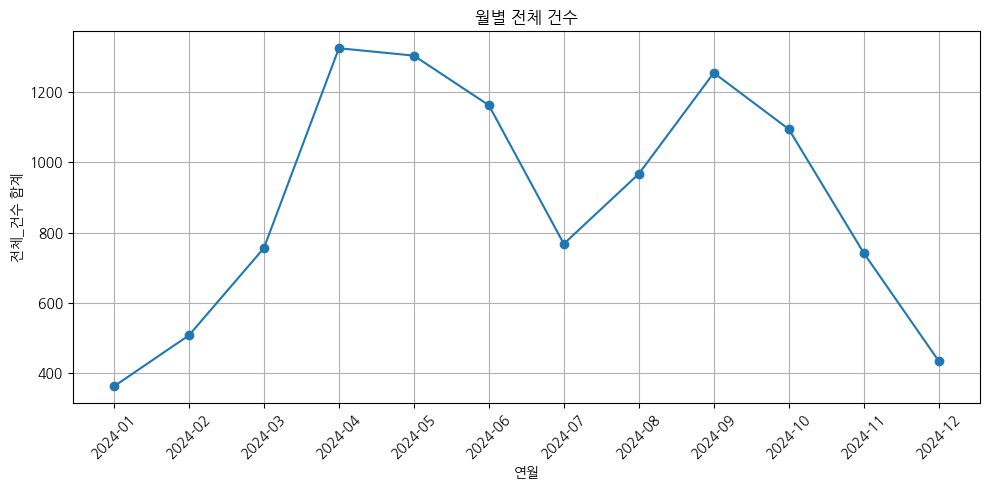

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import koreanize_matplotlib


df = pd.read_csv("../../Data/2024_st_hhj.csv")
df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])
df["연월"] = df["기준_날짜"].dt.to_period("M")

monthly_df = df.groupby("연월", as_index=False)["전체_건수"].sum()
monthly_df["연월"] = monthly_df["연월"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_df["연월"], monthly_df["전체_건수"], marker="o")
plt.title("월별 전체 건수")
plt.xlabel("연월")
plt.ylabel("전체_건수 합계")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

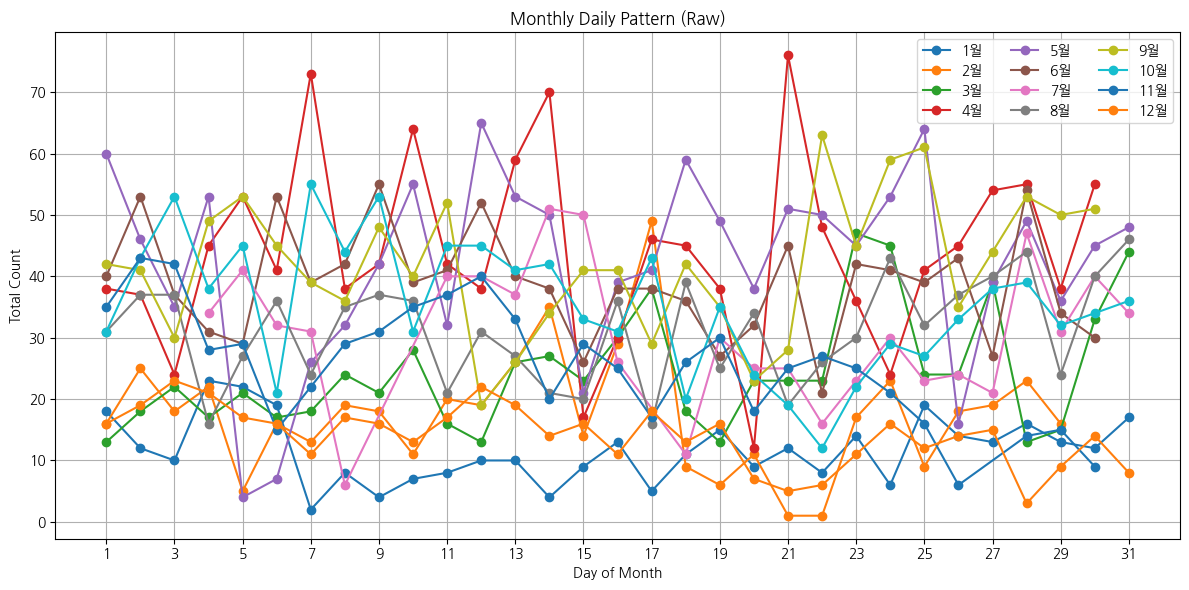

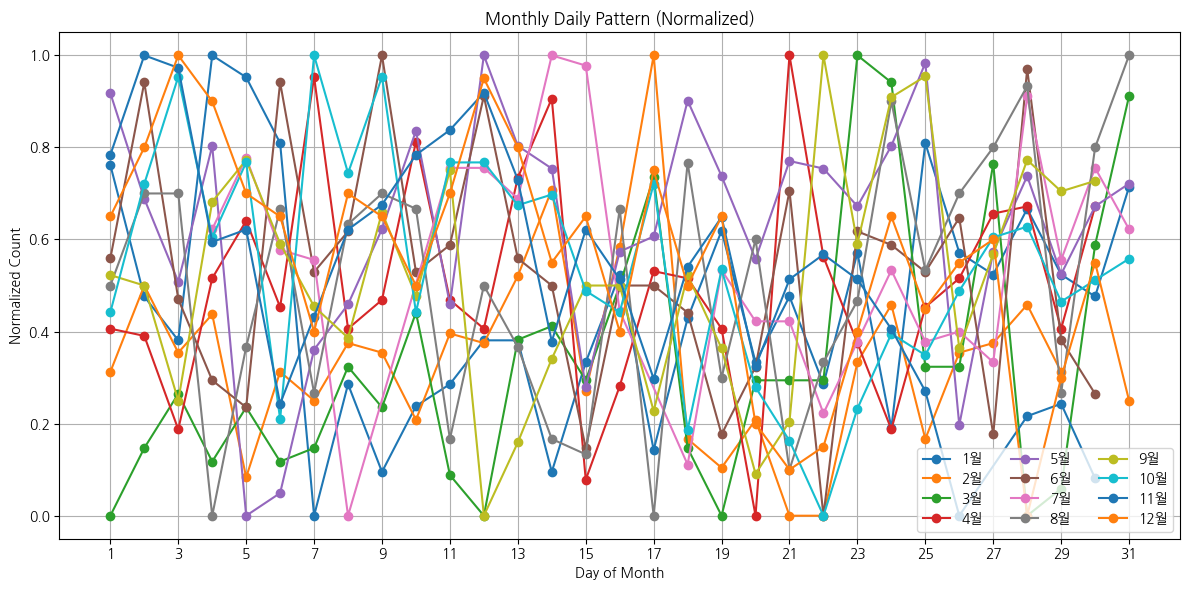

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/2024_st_hhj.csv")
df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])

# 월 / 일 컬럼 생성
df["월"] = df["기준_날짜"].dt.month
df["일"] = df["기준_날짜"].dt.day

# 월별-일별 전체 건수 집계
month_day_df = (
    df.groupby(["월", "일"], as_index=False)["전체_건수"]
      .sum()
      .sort_values(["월", "일"])
)

# 월별 정규화 (모양 비교용)
month_day_df["정규화_건수"] = (
    month_day_df.groupby("월")["전체_건수"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0)
)

# 1. 원본 그래프
plt.figure(figsize=(12, 6))
for month in sorted(month_day_df["월"].unique()):
    temp = month_day_df[month_day_df["월"] == month]
    plt.plot(temp["일"], temp["전체_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Daily Pattern (Raw)")
plt.xlabel("Day of Month")
plt.ylabel("Total Count")
plt.xticks(range(1, 32, 2))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# 2. 정규화 그래프 (모양 비교용)
plt.figure(figsize=(12, 6))
for month in sorted(month_day_df["월"].unique()):
    temp = month_day_df[month_day_df["월"] == month]
    plt.plot(temp["일"], temp["정규화_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Daily Pattern (Normalized)")
plt.xlabel("Day of Month")
plt.ylabel("Normalized Count")
plt.xticks(range(1, 32, 2))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

In [37]:
pivot_df = month_day_df.pivot(index="일", columns="월", values="정규화_건수")
corr_df = pivot_df.corr()

print(corr_df.round(3))

월      1      2      3      4      5      6      7      8      9      10  \
월                                                                          
1   1.000 -0.274 -0.165 -0.102 -0.082 -0.076  0.027  0.099  0.278 -0.272   
2  -0.274  1.000  0.329 -0.043  0.051  0.284  0.385 -0.072 -0.239  0.423   
3  -0.165  0.329  1.000 -0.039  0.062 -0.182 -0.160  0.266  0.096 -0.164   
4  -0.102 -0.043 -0.039  1.000  0.103  0.090  0.130 -0.220 -0.005  0.112   
5  -0.082  0.051  0.062  0.103  1.000  0.074 -0.119  0.076 -0.041 -0.191   
6  -0.076  0.284 -0.182  0.090  0.074  1.000  0.110  0.330 -0.180  0.245   
7   0.027  0.385 -0.160  0.130 -0.119  0.110  1.000 -0.244 -0.036  0.445   
8   0.099 -0.072  0.266 -0.220  0.076  0.330 -0.244  1.000  0.180 -0.056   
9   0.278 -0.239  0.096 -0.005 -0.041 -0.180 -0.036  0.180  1.000 -0.239   
10 -0.272  0.423 -0.164  0.112 -0.191  0.245  0.445 -0.056 -0.239  1.000   
11 -0.112 -0.089 -0.261 -0.140  0.236  0.092  0.038 -0.110 -0.235  0.345   
12 -0.004  0

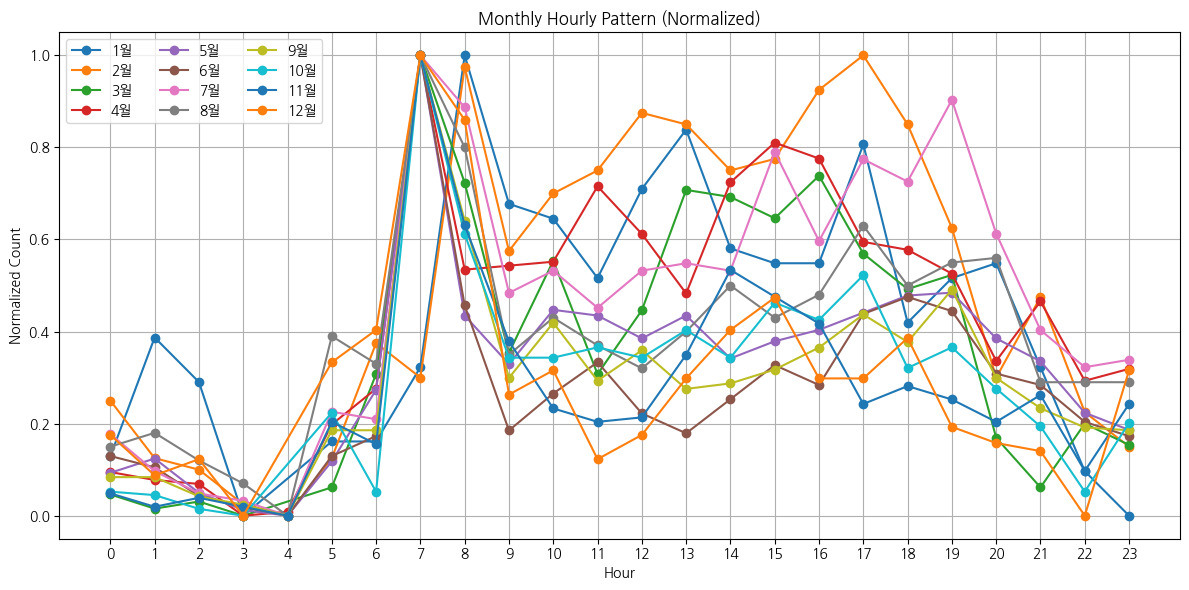

In [38]:
df["월"] = df["기준_날짜"].dt.month

month_hour_df = (
    df.groupby(["월", "시간대"], as_index=False)["전체_건수"]
      .sum()
      .sort_values(["월", "시간대"])
)

month_hour_df["정규화_건수"] = (
    month_hour_df.groupby("월")["전체_건수"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0)
)

plt.figure(figsize=(12, 6))
for month in sorted(month_hour_df["월"].unique()):
    temp = month_hour_df[month_hour_df["월"] == month]
    plt.plot(temp["시간대"], temp["정규화_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Hourly Pattern (Normalized)")
plt.xlabel("Hour")
plt.ylabel("Normalized Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

In [39]:
def month_group(m):
    if m in [1, 2, 12]:
        return "winter"
    elif m in [3, 4]:
        return "spring"
    elif m in [5, 6, 7, 8, 9, 10]:
        return "warm_peak"
    else:
        return "late_fall"

df["월그룹"] = df["기준_날짜"].dt.month.apply(month_group)

데이터 shape: (6834, 18)
   Unnamed: 0      기준_날짜  전체_건수  시간대  요일  월  주말여부  hour_sin  hour_cos  \
0           0 2024-01-01    2.0    2   0  1     0  0.500000  0.866025   
1           1 2024-01-01    1.0    9   0  1     0  0.707107 -0.707107   
2           2 2024-01-01    1.0   10   0  1     0  0.500000 -0.866025   
3           3 2024-01-01    1.0   13   0  1     0 -0.258819 -0.965926   
4           4 2024-01-01    1.0   14   0  1     0 -0.500000 -0.866025   

   온도_scaled  습도_scaled  강수량_scaled  적설량_scaled  시작_대여소_ID_ST-1023  \
0  -1.767594   1.049954   -0.133858   -0.037662              False   
1  -1.655731   1.049954   -0.133858   -0.037662              False   
2  -1.381159   1.049954   -0.133858   -0.037662              False   
3  -1.025232   0.014351    0.040354   -0.037662               True   
4  -1.025232  -0.140990   -0.133858   -0.037662              False   

   시작_대여소_ID_ST-1024  시작_대여소_ID_ST-450       연월  일  
0               True             False  2024-01  1  
1           

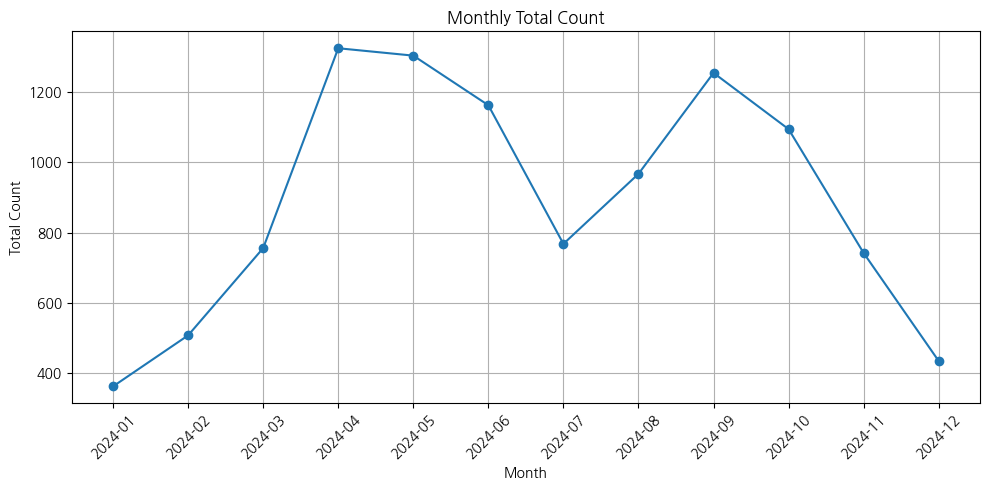


[월별 전체 건수]
         연월   전체_건수
0   2024-01   363.0
1   2024-02   508.0
2   2024-03   756.0
3   2024-04  1324.0
4   2024-05  1303.0
5   2024-06  1162.0
6   2024-07   768.0
7   2024-08   967.0
8   2024-09  1254.0
9   2024-10  1094.0
10  2024-11   742.0
11  2024-12   435.0


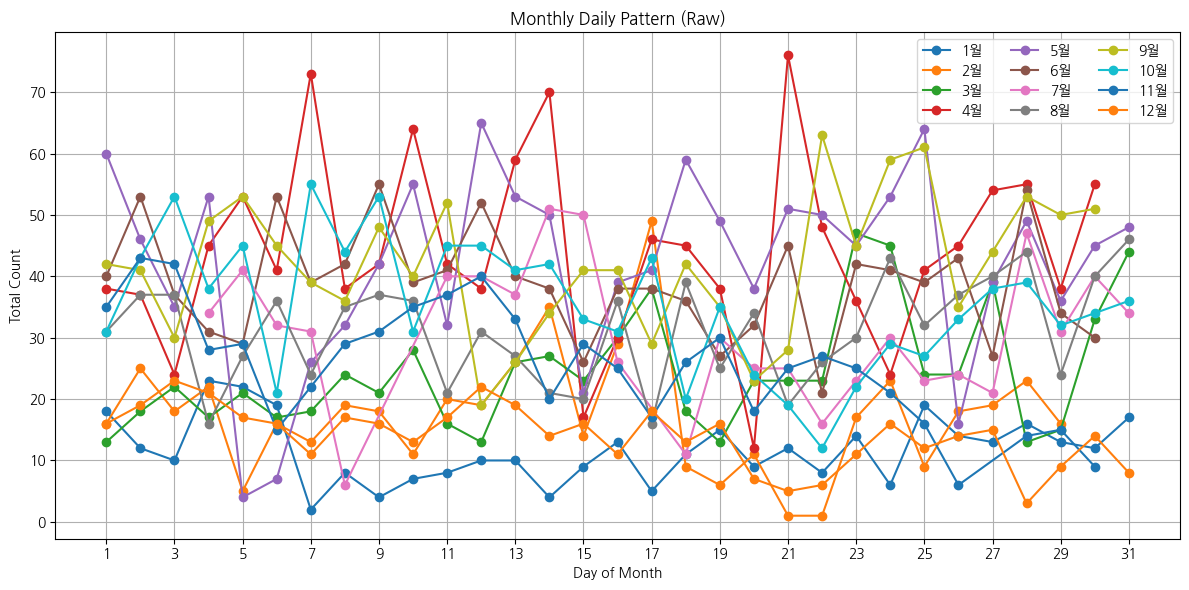

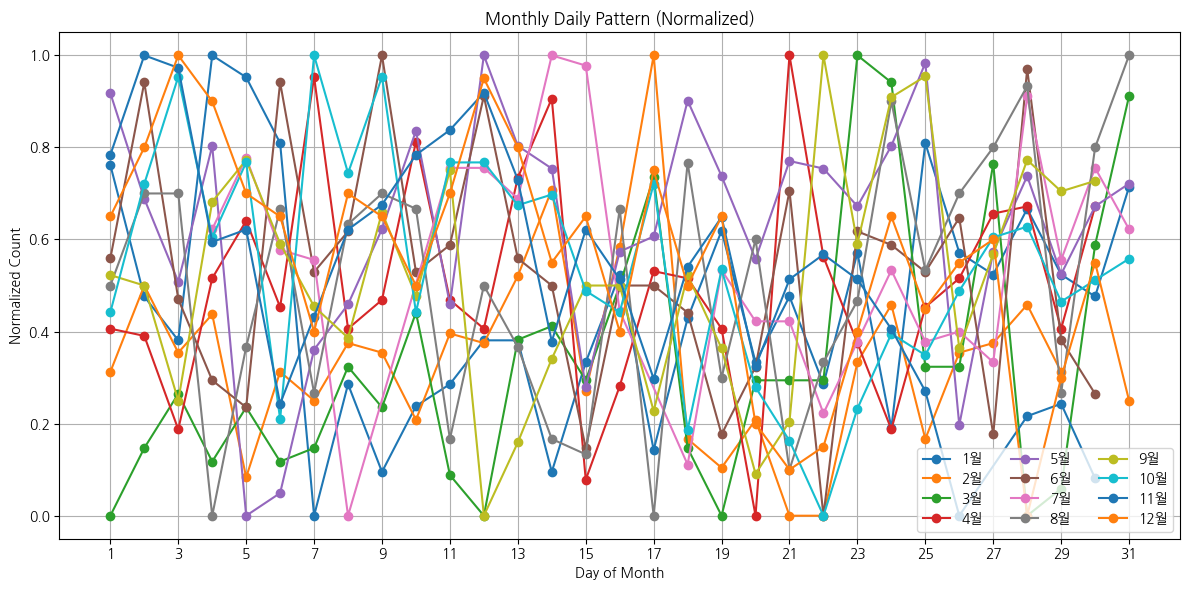


[월별-일별 패턴 데이터]
    월   일  전체_건수    정규화_건수
0   1   1   18.0  0.761905
1   1   2   12.0  0.476190
2   1   3   10.0  0.380952
3   1   4   23.0  1.000000
4   1   5   22.0  0.952381
5   1   6   19.0  0.809524
6   1   7    2.0  0.000000
7   1   8    8.0  0.285714
8   1   9    4.0  0.095238
9   1  10    7.0  0.238095
10  1  11    8.0  0.285714
11  1  12   10.0  0.380952
12  1  13   10.0  0.380952
13  1  14    4.0  0.095238
14  1  15    9.0  0.333333
15  1  16   13.0  0.523810
16  1  17    5.0  0.142857
17  1  18   11.0  0.428571
18  1  19   15.0  0.619048
19  1  20    9.0  0.333333
20  1  21   12.0  0.476190
21  1  22    8.0  0.285714
22  1  23   14.0  0.571429
23  1  24    6.0  0.190476
24  1  25   19.0  0.809524
25  1  26   14.0  0.571429
26  1  27   13.0  0.523810
27  1  28   16.0  0.666667
28  1  29   13.0  0.523810
29  1  30   12.0  0.476190


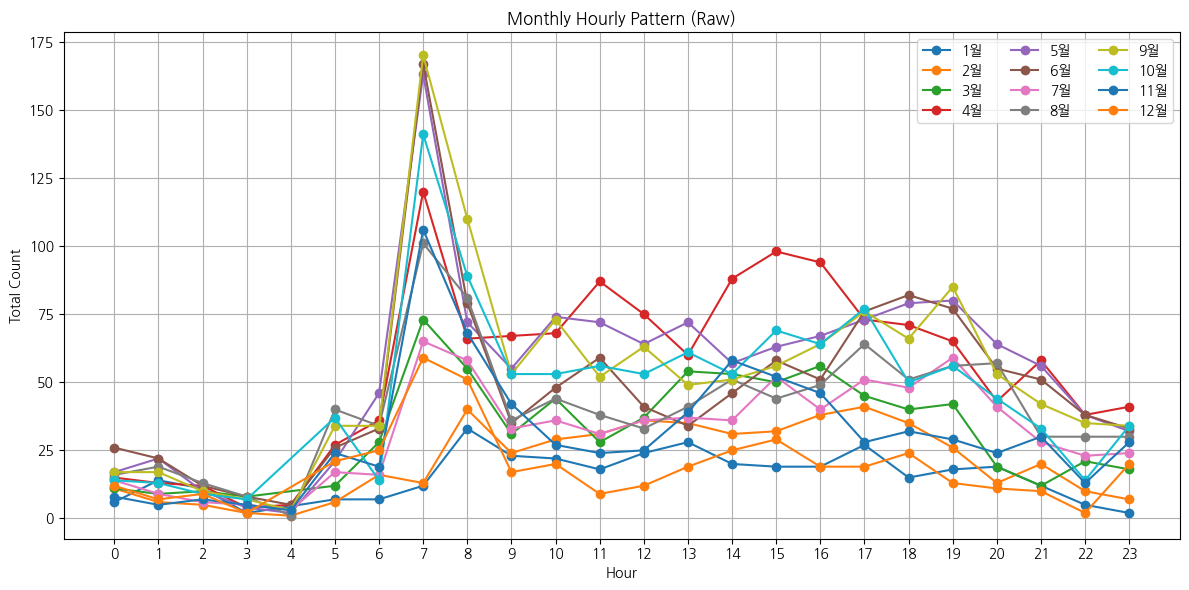

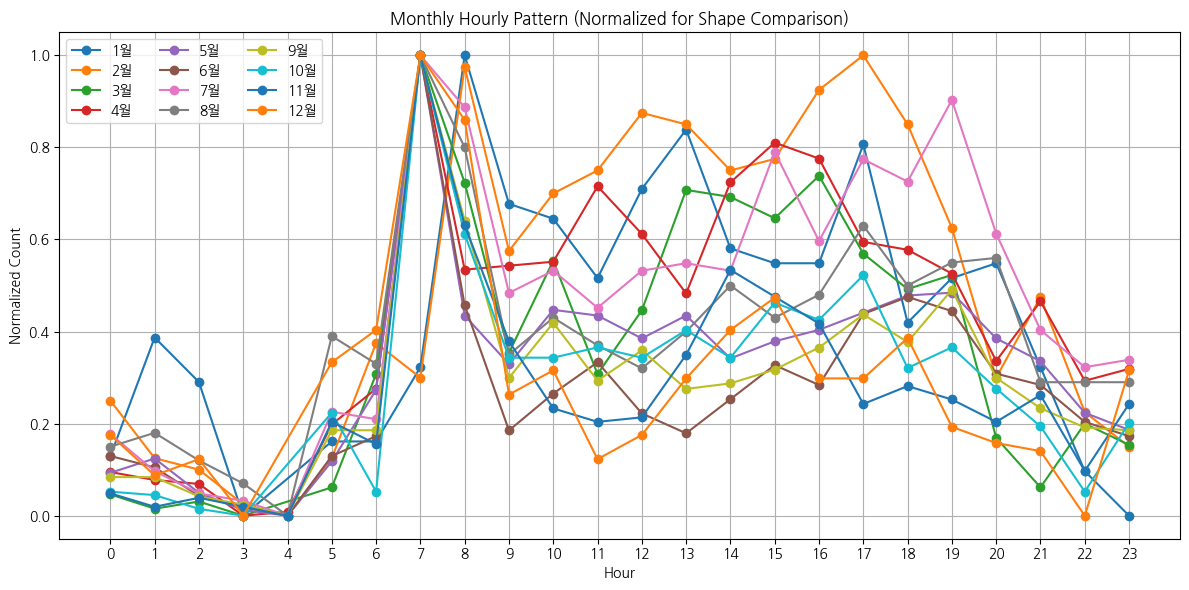


[월별-시간대별 패턴 데이터]
    월  시간대  전체_건수    정규화_건수
0   1    0    6.0  0.129032
1   1    1   14.0  0.387097
2   1    2   11.0  0.290323
3   1    3    2.0  0.000000
4   1    5    7.0  0.161290
5   1    6    7.0  0.161290
6   1    7   12.0  0.322581
7   1    8   33.0  1.000000
8   1    9   23.0  0.677419
9   1   10   22.0  0.645161
10  1   11   18.0  0.516129
11  1   12   24.0  0.709677
12  1   13   28.0  0.838710
13  1   14   20.0  0.580645
14  1   15   19.0  0.548387
15  1   16   19.0  0.548387
16  1   17   27.0  0.806452
17  1   18   15.0  0.419355
18  1   19   18.0  0.516129
19  1   20   19.0  0.548387
20  1   21   12.0  0.322581
21  1   22    5.0  0.096774
22  1   23    2.0  0.000000
23  2    0   11.0  0.250000
24  2    1    6.0  0.125000
25  2    2    5.0  0.100000
26  2    3    2.0  0.025000
27  2    4    1.0  0.000000
28  2    5    6.0  0.125000
29  2    6   16.0  0.375000

[월별 시간대 패턴 유사도(상관계수)]
월      1      2      3      4      5      6      7      8      9      10  \
월              

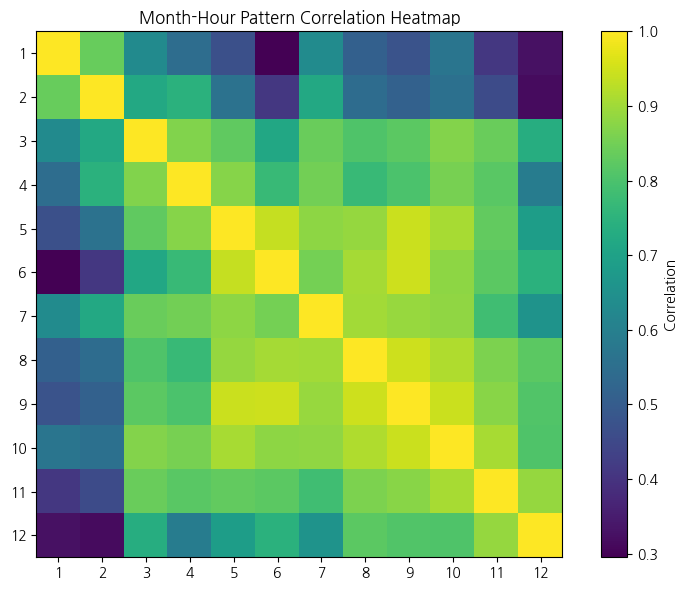

ValueError: The condensed distance matrix must contain only finite values.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# =============================
# 1. 데이터 읽기
# =============================
df = pd.read_csv("../../Data/2024_st_hhj.csv")
df["기준_날짜"] = pd.to_datetime(df["기준_날짜"])

# 파생 컬럼
df["연월"] = df["기준_날짜"].dt.to_period("M")
df["월"] = df["기준_날짜"].dt.month
df["일"] = df["기준_날짜"].dt.day

print("데이터 shape:", df.shape)
print(df.head())


# =============================
# 2. 월별 전체 건수 선그래프
# =============================
monthly_df = (
    df.groupby("연월", as_index=False)["전체_건수"]
      .sum()
)

monthly_df["연월"] = monthly_df["연월"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_df["연월"], monthly_df["전체_건수"], marker="o")
plt.title("Monthly Total Count")
plt.xlabel("Month")
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n[월별 전체 건수]")
print(monthly_df)


# =============================
# 3. 월별-일별 패턴 그래프
# =============================
month_day_df = (
    df.groupby(["월", "일"], as_index=False)["전체_건수"]
      .sum()
      .sort_values(["월", "일"])
      .reset_index(drop=True)
)

# 월별 정규화 (모양 비교용)
month_day_df["정규화_건수"] = (
    month_day_df.groupby("월")["전체_건수"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0)
)

# 원본 그래프
plt.figure(figsize=(12, 6))
for month in sorted(month_day_df["월"].unique()):
    temp = month_day_df[month_day_df["월"] == month]
    plt.plot(temp["일"], temp["전체_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Daily Pattern (Raw)")
plt.xlabel("Day of Month")
plt.ylabel("Total Count")
plt.xticks(range(1, 32, 2))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# 정규화 그래프
plt.figure(figsize=(12, 6))
for month in sorted(month_day_df["월"].unique()):
    temp = month_day_df[month_day_df["월"] == month]
    plt.plot(temp["일"], temp["정규화_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Daily Pattern (Normalized)")
plt.xlabel("Day of Month")
plt.ylabel("Normalized Count")
plt.xticks(range(1, 32, 2))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

print("\n[월별-일별 패턴 데이터]")
print(month_day_df.head(30))


# =============================
# 4. 월별-시간대별 패턴 그래프
# =============================
month_hour_df = (
    df.groupby(["월", "시간대"], as_index=False)["전체_건수"]
      .sum()
      .sort_values(["월", "시간대"])
      .reset_index(drop=True)
)

# 월별 정규화
month_hour_df["정규화_건수"] = (
    month_hour_df.groupby("월")["전체_건수"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0)
)

# 원본 그래프
plt.figure(figsize=(12, 6))
for month in sorted(month_hour_df["월"].unique()):
    temp = month_hour_df[month_hour_df["월"] == month]
    plt.plot(temp["시간대"], temp["전체_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Hourly Pattern (Raw)")
plt.xlabel("Hour")
plt.ylabel("Total Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# 정규화 그래프
plt.figure(figsize=(12, 6))
for month in sorted(month_hour_df["월"].unique()):
    temp = month_hour_df[month_hour_df["월"] == month]
    plt.plot(temp["시간대"], temp["정규화_건수"], marker="o", label=f"{month}월")

plt.title("Monthly Hourly Pattern (Normalized for Shape Comparison)")
plt.xlabel("Hour")
plt.ylabel("Normalized Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

print("\n[월별-시간대별 패턴 데이터]")
print(month_hour_df.head(30))


# =============================
# 5. 월별 시간대 패턴 유사도 표
# =============================
pivot_df = month_hour_df.pivot(index="시간대", columns="월", values="정규화_건수")
corr_df = pivot_df.corr().round(3)

print("\n[월별 시간대 패턴 유사도(상관계수)]")
print(corr_df)

# 상위 유사 월쌍 정리
pairs = []
months = list(corr_df.index)

for i in range(len(months)):
    for j in range(i + 1, len(months)):
        m1, m2 = months[i], months[j]
        pairs.append((m1, m2, corr_df.loc[m1, m2]))

pair_df = pd.DataFrame(pairs, columns=["월1", "월2", "상관계수"])
pair_df = pair_df.sort_values("상관계수", ascending=False).reset_index(drop=True)

print("\n[유사 월쌍 TOP 15]")
print(pair_df.head(15))


# =============================
# 6. 히트맵
# =============================
plt.figure(figsize=(8, 6))
plt.imshow(corr_df, interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Month-Hour Pattern Correlation Heatmap")
plt.tight_layout()
plt.show()


# =============================
# 7. 덴드로그램
# =============================
Z = linkage(pivot_df.T, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=pivot_df.columns.tolist())
plt.title("Monthly Pattern Clustering")
plt.xlabel("Month")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


# =============================
# 8. 월 그룹 만들기 예시
# =============================
def month_group_num(m):
    if m in [1, 2, 12]:
        return 0   # 겨울
    elif m in [3, 4]:
        return 1   # 봄
    elif m in [5, 6, 7, 8, 9, 10]:
        return 2   # 따뜻한 시기
    else:
        return 3   # 늦가을

df["월그룹"] = df["월"].apply(month_group_num)

print("\n[월/월그룹 예시]")
print(df[["기준_날짜", "월", "월그룹"]].head(20))

In [ ]:

from __future__ import annotations

import warnings
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

try:
    import optuna
except Exception:
    optuna = None

warnings.filterwarnings("ignore")

# =========================================================
# 0. 경로 설정
# =========================================================
DATA_PATH = Path("../../Data/sort_data/2024_data.parquet")
POP_PATH = Path("../../Data/pop_data.csv")
SUBWAY_RIDERSHIP_PATH = Path("../../Data/서울교통공사_역별_시간대별_승하차인원.csv")
# 아래 파일은 있으면 사용, 없으면 생략
SUBWAY_STATION_META_PATH = Path("../../Data/서울교통공사_역사좌표.csv")
STATION_META_PATH = Path("../../Data/station_meta.csv")
OUTPUT_DIR = Path("./outputs_bike_pipeline")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# =========================================================
# 1. 유틸
# =========================================================
def ensure_datetime(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    return df

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def safe_get_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    return None

def add_holiday_features(df: pd.DataFrame, date_col: str = "기준_날짜") -> pd.DataFrame:
    df = df.copy()
    # 한국 공휴일 라이브러리가 있으면 사용, 없으면 주말만 restingday로 설정
    try:
        import holidays
        kr_holidays = holidays.KR(years=sorted(df[date_col].dt.year.unique()))
        holiday_flag = df[date_col].dt.date.astype(object).isin(kr_holidays)
    except Exception:
        holiday_flag = pd.Series(False, index=df.index)

    weekday_num = df[date_col].dt.dayofweek  # Mon=0
    df["is_weekday"] = (weekday_num < 5).astype(int)
    df["is_restingday"] = ((weekday_num >= 5) | holiday_flag).astype(int)

    # 요청대로 원핫도 같이 생성
    weekday_ohe = pd.get_dummies(df["is_weekday"], prefix="is_weekday")
    resting_ohe = pd.get_dummies(df["is_restingday"], prefix="is_restingday")
    df = pd.concat([df, weekday_ohe, resting_ohe], axis=1)
    return df

def add_day_night_features(df: pd.DataFrame, hour_col: str = "hour") -> pd.DataFrame:
    df = df.copy()
    df["is_night"] = df[hour_col].isin([0,1,2,3,4,5,22,23]).astype(int)
    df["is_daytime"] = df[hour_col].between(6, 21).astype(int)

    night_ohe = pd.get_dummies(df["is_night"], prefix="is_night")
    daytime_ohe = pd.get_dummies(df["is_daytime"], prefix="is_daytime")
    df = pd.concat([df, night_ohe, daytime_ohe], axis=1)

    df["hour_business"] = df[hour_col].isin([8,9,10,11,12,13,14,15,16,17]).astype(int)
    df["hour_transit"] = df[hour_col].isin([7,8,9,17,18,19,20]).astype(int)
    return df

def add_weather_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rain_col = safe_get_col(df, ["강수량", "1시간강수량", "precipitation", "rainfall"])
    snow_col = safe_get_col(df, ["적설량", "snowfall", "snow_depth"])

    if rain_col:
        df["rain_flag"] = (pd.to_numeric(df[rain_col], errors="coerce").fillna(0) > 0).astype(int)
    else:
        df["rain_flag"] = 0

    if snow_col:
        df["snow_flag"] = (pd.to_numeric(df[snow_col], errors="coerce").fillna(0) > 0).astype(int)
    else:
        df["snow_flag"] = 0
    return df

def infer_target_col(df: pd.DataFrame) -> str:
    for c in ["전체_건수", "count", "target", "수요", "대여건수"]:
        if c in df.columns:
            return c
    raise ValueError("타깃 컬럼을 찾지 못했습니다. 예: 전체_건수")

def numeric_feature_list(df: pd.DataFrame, target_col: str, exclude: List[str]) -> List[str]:
    cols = []
    for c in df.columns:
        if c in exclude or c == target_col:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

def plot_feature_vs_target(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    outdir: Path,
    max_features: int = 24,
):
    outdir.mkdir(exist_ok=True, parents=True)
    selected = feature_cols[:max_features]
    for col in selected:
        fig = plt.figure(figsize=(7, 4))
        plt.scatter(df[col], df[target_col], s=10, alpha=0.35)
        plt.title(f"{col} vs {target_col}")
        plt.xlabel(col)
        plt.ylabel(target_col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(outdir / f"scatter_{col}.png", dpi=150)
        plt.close(fig)

def compare_raw_log_poly(
    df: pd.DataFrame, feature_cols: List[str], target_col: str, outdir: Path
) -> pd.DataFrame:
    """
    month/day/hour 제외, 각 feature에 대해
    raw / log1p / poly2 가 target과 어떤 관계를 갖는지 간단 비교.
    수치 기준: |pearson| 와 mutual information
    """
    records = []
    for col in feature_cols:
        if col in ["month", "day", "hour"]:
            continue

        x = pd.to_numeric(df[col], errors="coerce")
        y = pd.to_numeric(df[target_col], errors="coerce")
        valid = x.notna() & y.notna()
        if valid.sum() < 30:
            continue

        x0 = x[valid].to_numpy().reshape(-1, 1)
        y0 = y[valid].to_numpy()

        raw_abs_corr = abs(pd.Series(x0.ravel()).corr(pd.Series(y0)))
        raw_mi = mutual_info_regression(x0, y0, random_state=42)[0]

        if (x0 >= 0).all():
            x_log = np.log1p(x0)
            log_abs_corr = abs(pd.Series(x_log.ravel()).corr(pd.Series(y0)))
            log_mi = mutual_info_regression(x_log, y0, random_state=42)[0]
        else:
            log_abs_corr, log_mi = np.nan, np.nan

        poly = PolynomialFeatures(degree=2, include_bias=False)
        x_poly = poly.fit_transform(x0)
        poly_mi = mutual_info_regression(x_poly, y0, random_state=42).sum()
        poly_abs_corr = max(
            abs(pd.Series(x_poly[:, i]).corr(pd.Series(y0))) for i in range(x_poly.shape[1])
        )

        best = pd.Series({
            "raw": np.nanmean([raw_abs_corr, raw_mi]),
            "log1p": np.nanmean([log_abs_corr, log_mi]),
            "poly2": np.nanmean([poly_abs_corr, poly_mi]),
        }).idxmax()

        records.append({
            "feature": col,
            "raw_abs_corr": raw_abs_corr,
            "raw_mi": raw_mi,
            "log_abs_corr": log_abs_corr,
            "log_mi": log_mi,
            "poly_abs_corr": poly_abs_corr,
            "poly_mi": poly_mi,
            "best_transform": best,
        })

        # 시각화
        fig = plt.figure(figsize=(12, 3.6))
        plt.subplot(1, 3, 1)
        plt.scatter(x0, y0, s=8, alpha=0.25)
        plt.title(f"{col} raw")

        plt.subplot(1, 3, 2)
        if (x0 >= 0).all():
            plt.scatter(np.log1p(x0), y0, s=8, alpha=0.25)
            plt.title(f"{col} log1p")
        else:
            plt.text(0.5, 0.5, "negative exists", ha="center", va="center")
            plt.title(f"{col} log1p skip")

        plt.subplot(1, 3, 3)
        plt.scatter(x0**2, y0, s=8, alpha=0.25)
        plt.title(f"{col} poly2(x^2)")
        plt.tight_layout()
        plt.savefig(outdir / f"transform_compare_{col}.png", dpi=150)
        plt.close(fig)

    res = pd.DataFrame(records).sort_values(["best_transform", "raw_mi"], ascending=[True, False])
    res.to_csv(outdir / "feature_transform_comparison.csv", index=False, encoding="utf-8-sig")
    return res

def apply_feature_transforms(df: pd.DataFrame, transform_df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for _, row in transform_df.iterrows():
        col = row["feature"]
        best = row["best_transform"]
        if col not in df.columns:
            continue
        x = pd.to_numeric(df[col], errors="coerce")
        if best == "log1p" and (x.dropna() >= 0).all():
            df[f"{col}_log1p"] = np.log1p(x)
        elif best == "poly2":
            df[f"{col}_sq"] = x ** 2
    return df

def add_subway_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    station_meta + subway station meta + ridership가 모두 있을 때만 사용.
    없으면 조용히 스킵.
    """
    if not (STATION_META_PATH.exists() and SUBWAY_STATION_META_PATH.exists() and SUBWAY_RIDERSHIP_PATH.exists()):
        print("[INFO] 지하철 관련 보조 파일이 부족하여 subway feature 단계는 skip합니다.")
        for c in ["near_subway_200m", "commute_peak_in", "commute_peak_out", "is_airport_rail", "is_ktx"]:
            df[c] = 0
        return df

    bike_meta = pd.read_csv(STATION_META_PATH)
    subway_meta = pd.read_csv(SUBWAY_STATION_META_PATH)
    ridership = pd.read_csv(SUBWAY_RIDERSHIP_PATH)

    bike_id_col = safe_get_col(bike_meta, ["대여소_ID", "시작_대여소_ID", "station_id"])
    bike_lat_col = safe_get_col(bike_meta, ["위도", "lat", "latitude"])
    bike_lon_col = safe_get_col(bike_meta, ["경도", "lon", "longitude"])
    sub_name_col = safe_get_col(subway_meta, ["역명", "station_name"])
    sub_lat_col = safe_get_col(subway_meta, ["위도", "lat", "latitude"])
    sub_lon_col = safe_get_col(subway_meta, ["경도", "lon", "longitude"])
    line_col = safe_get_col(subway_meta, ["호선명", "line", "노선명"])

    rider_name_col = safe_get_col(ridership, ["역명", "station_name"])
    hour_col = safe_get_col(ridership, ["시간대", "hour"])
    in_col = safe_get_col(ridership, ["승차인원", "승차", "in_cnt"])
    out_col = safe_get_col(ridership, ["하차인원", "하차", "out_cnt"])

    if None in [bike_id_col, bike_lat_col, bike_lon_col, sub_name_col, sub_lat_col, sub_lon_col]:
        print("[INFO] 지하철/대여소 좌표 컬럼명이 예상과 달라 subway feature 단계는 skip합니다.")
        for c in ["near_subway_200m", "commute_peak_in", "commute_peak_out", "is_airport_rail", "is_ktx"]:
            df[c] = 0
        return df

    # 자전거 대여소별 가장 가까운 지하철역 찾기
    pairs = []
    for _, b in bike_meta[[bike_id_col, bike_lat_col, bike_lon_col]].drop_duplicates().iterrows():
        tmp = subway_meta[[sub_name_col, sub_lat_col, sub_lon_col] + ([line_col] if line_col else [])].copy()
        tmp["dist_m"] = haversine_m(
            b[bike_lat_col], b[bike_lon_col],
            tmp[sub_lat_col].values, tmp[sub_lon_col].values
        )
        row = tmp.sort_values("dist_m").iloc[0].to_dict()
        row[bike_id_col] = b[bike_id_col]
        pairs.append(row)
    near_df = pd.DataFrame(pairs)

    near_df["near_subway_200m"] = (near_df["dist_m"] <= 200).astype(int)

    if rider_name_col and hour_col and in_col and out_col:
        ridership[hour_col] = pd.to_numeric(ridership[hour_col], errors="coerce")
        in_peak = ridership[ridership[hour_col].isin([7,8,9])].groupby(rider_name_col)[in_col].mean().rename("commute_peak_in")
        out_peak = ridership[ridership[hour_col].isin([17,18,19,20])].groupby(rider_name_col)[out_col].mean().rename("commute_peak_out")
        near_df = near_df.merge(in_peak, left_on=sub_name_col, right_index=True, how="left")
        near_df = near_df.merge(out_peak, left_on=sub_name_col, right_index=True, how="left")
    else:
        near_df["commute_peak_in"] = np.nan
        near_df["commute_peak_out"] = np.nan

    if line_col:
        near_df["is_airport_rail"] = near_df[line_col].astype(str).str.contains("공항", na=False).astype(int)
        near_df["is_ktx"] = near_df[line_col].astype(str).str.contains("KTX", na=False).astype(int)
    else:
        near_df["is_airport_rail"] = 0
        near_df["is_ktx"] = 0

    join_key = "시작_대여소_ID" if "시작_대여소_ID" in df.columns else bike_id_col
    near_df = near_df.rename(columns={bike_id_col: join_key})
    keep_cols = [join_key, "near_subway_200m", "commute_peak_in", "commute_peak_out", "is_airport_rail", "is_ktx"]
    df = df.merge(near_df[keep_cols], on=join_key, how="left")

    fill_cols = ["near_subway_200m", "commute_peak_in", "commute_peak_out", "is_airport_rail", "is_ktx"]
    for c in fill_cols:
        df[c] = df[c].fillna(0)
    return df

def add_pop_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    pop_data.csv 구조를 모르므로 가능한 컬럼명 후보 기반으로 조인.
    station 좌표 메타파일이 없으면 skip.
    """
    if not (POP_PATH.exists() and STATION_META_PATH.exists()):
        print("[INFO] pop/station_meta 파일이 부족하여 pop feature 단계는 skip합니다.")
        for c in [
            "business_ratio", "business_index", "residential_ratio", "residential_index",
            "transit_ratio", "transit_index", "leisure_ratio", "leisure_index",
            "commute_ratio", "commute_index"
        ]:
            df[c] = np.nan
        return df

    pop = pd.read_csv(POP_PATH)
    station_meta = pd.read_csv(STATION_META_PATH)

    # 가장 쉬운 경우: 이미 대여소_ID 기준 feature가 있을 때
    id_col = safe_get_col(pop, ["대여소_ID", "station_id", "시작_대여소_ID"])
    if id_col:
        join_key = "시작_대여소_ID" if "시작_대여소_ID" in df.columns else id_col
        pop = pop.rename(columns={id_col: join_key})
        keep = [join_key] + [c for c in pop.columns if c != join_key]
        return df.merge(pop[keep], on=join_key, how="left")

    # 좌표 기반 최근접 매칭 시도
    st_id = safe_get_col(station_meta, ["대여소_ID", "시작_대여소_ID", "station_id"])
    st_lat = safe_get_col(station_meta, ["위도", "lat", "latitude"])
    st_lon = safe_get_col(station_meta, ["경도", "lon", "longitude"])
    pp_lat = safe_get_col(pop, ["위도", "lat", "latitude"])
    pp_lon = safe_get_col(pop, ["경도", "lon", "longitude"])

    feature_candidates = [
        "business_ratio", "business_index", "residential_ratio", "residential_index",
        "transit_ratio", "transit_index", "leisure_ratio", "leisure_index",
        "commute_ratio", "commute_index"
    ]
    present_feats = [c for c in feature_candidates if c in pop.columns]

    if None in [st_id, st_lat, st_lon, pp_lat, pp_lon] or not present_feats:
        print("[INFO] pop_data 컬럼이 예상과 달라 pop feature 단계는 skip합니다.")
        for c in feature_candidates:
            if c not in df.columns:
                df[c] = np.nan
        return df

    rows = []
    for _, s in station_meta[[st_id, st_lat, st_lon]].drop_duplicates().iterrows():
        tmp = pop[[pp_lat, pp_lon] + present_feats].copy()
        tmp["dist_m"] = haversine_m(
            s[st_lat], s[st_lon],
            tmp[pp_lat].values, tmp[pp_lon].values
        )
        near = tmp[tmp["dist_m"] <= 200]
        row = {st_id: s[st_id]}
        for f in present_feats:
            row[f] = near[f].mean() if len(near) else np.nan
        rows.append(row)
    feat_df = pd.DataFrame(rows)

    join_key = "시작_대여소_ID" if "시작_대여소_ID" in df.columns else st_id
    feat_df = feat_df.rename(columns={st_id: join_key})
    return df.merge(feat_df, on=join_key, how="left")

def split_train_valid_test(df: pd.DataFrame, date_col: str = "기준_날짜") -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train = df[df[date_col] < "2024-11-01"].copy()
    valid = df[(df[date_col] >= "2024-11-01") & (df[date_col] < "2024-12-01")].copy()
    test = df[df[date_col] >= "2024-12-01"].copy()
    return train, valid, test

def add_lag_rolling_features(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """
    station + datetime 정렬 후 과거 정보만 사용.
    shift를 반드시 먼저 적용.
    """
    df = df.copy()
    date_col = "기준_날짜"
    station_col = "시작_대여소_ID" if "시작_대여소_ID" in df.columns else None
    dt_col = "datetime"

    if dt_col not in df.columns:
        df[dt_col] = pd.to_datetime(df[date_col]) + pd.to_timedelta(df["hour"], unit="h")

    sort_cols = [station_col, dt_col] if station_col else [dt_col]
    df = df.sort_values(sort_cols).copy()

    group_obj = df.groupby(station_col) if station_col else [(None, df)]

    def _make(group: pd.DataFrame) -> pd.DataFrame:
        s = group[target_col]
        group["lag_1hr"] = s.shift(1)
        group["lag_2hr"] = s.shift(2)
        group["lag_3hr"] = s.shift(3)
        group["lag_24hr"] = s.shift(24)
        group["lag_168hr"] = s.shift(168)

        shifted = s.shift(1)
        group["rolling_mean_3hr"] = shifted.rolling(3).mean()
        group["rolling_mean_6hr"] = shifted.rolling(6).mean()
        group["rolling_mean_24hr"] = shifted.rolling(24).mean()
        group["rolling_std_24hr"] = shifted.rolling(24).std()
        return group

    if station_col:
        df = group_obj.apply(_make).reset_index(drop=True)
    else:
        df = _make(df)
    return df

def prepare_xy(
    train: pd.DataFrame,
    valid: pd.DataFrame,
    test: pd.DataFrame,
    target_col: str,
    drop_cols: List[str],
):
    feature_cols = [c for c in train.columns if c not in drop_cols + [target_col]]
    # train 기준으로 숫자/더미만 사용
    usable = []
    for c in feature_cols:
        if pd.api.types.is_numeric_dtype(train[c]):
            usable.append(c)

    X_train = train[usable].copy()
    X_valid = valid[usable].copy()
    X_test = test[usable].copy()

    y_train = train[target_col].copy()
    y_valid = valid[target_col].copy()
    y_test = test[target_col].copy()

    # 학습/예측 모델 편의를 위해 NaN은 그대로 두되,
    # RandomForestRegressor가 NaN 처리 안 될 수 있어 단순 대치
    med = X_train.median(numeric_only=True)
    X_train = X_train.fillna(med)
    X_valid = X_valid.fillna(med)
    X_test = X_test.fillna(med)

    return X_train, y_train, X_valid, y_valid, X_test, y_test, usable

def get_sample_weights(df: pd.DataFrame) -> np.ndarray:
    w = np.ones(len(df), dtype=float)
    if "hour" in df.columns:
        w += np.where(df["hour"].isin([7,8,9]), 0.5, 0.0)
        w += np.where(df["hour"].isin([17,18,19,20]), 0.5, 0.0)
    return w

def eval_regression(y_true, y_pred) -> Dict[str, float]:
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }

def plot_predictions(y_true, y_pred, title_prefix: str, outdir: Path):
    # scatter
    fig = plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.35)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{title_prefix} Scatter")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(outdir / f"{title_prefix}_scatter.png", dpi=150)
    plt.close(fig)

    # residual
    residual = y_true - y_pred
    fig = plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, residual, s=10, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"{title_prefix} Residual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(outdir / f"{title_prefix}_residual.png", dpi=150)
    plt.close(fig)

    # sample plot
    n = min(300, len(y_true))
    fig = plt.figure(figsize=(12, 4))
    plt.plot(np.arange(n), np.asarray(y_true)[:n], label="actual")
    plt.plot(np.arange(n), np.asarray(y_pred)[:n], label="pred")
    plt.title(f"{title_prefix} Sample Plot (first {n})")
    plt.xlabel("Index")
    plt.ylabel("Target")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(outdir / f"{title_prefix}_sample.png", dpi=150)
    plt.close(fig)

def feature_selection_report(X_train: pd.DataFrame, y_train: pd.Series, outdir: Path) -> pd.DataFrame:
    # 1) RandomForest importance
    base = RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=2, random_state=42, n_jobs=-1
    )
    base.fit(X_train, y_train)
    imp = pd.DataFrame({
        "feature": X_train.columns,
        "rf_importance": base.feature_importances_,
    })

    # 2) 결측/상수/중복상관
    nunique = X_train.nunique(dropna=False)
    stats = pd.DataFrame({
        "feature": X_train.columns,
        "nunique": [nunique[c] for c in X_train.columns],
        "missing_ratio": [X_train[c].isna().mean() for c in X_train.columns],
        "zero_ratio": [(X_train[c] == 0).mean() if pd.api.types.is_numeric_dtype(X_train[c]) else np.nan for c in X_train.columns],
    })

    corr = X_train.corr(numeric_only=True).abs()
    high_corr_map = {}
    for c in corr.columns:
        vals = corr[c].drop(c, errors="ignore")
        high_corr_map[c] = vals[vals >= 0.95].index.tolist()
    stats["high_corr_partners"] = stats["feature"].map(high_corr_map)

    report = stats.merge(imp, on="feature", how="left").sort_values("rf_importance")
    report["drop_must"] = (
        (report["nunique"] <= 1) |
        ((report["rf_importance"].fillna(0) < 0.001) & (report["missing_ratio"] >= 0.9))
    )
    report["drop_consider"] = (
        (~report["drop_must"]) &
        (
            (report["rf_importance"].fillna(0) < 0.003) |
            (report["high_corr_partners"].apply(lambda x: len(x) if isinstance(x, list) else 0) >= 1)
        )
    )

    report.to_csv(outdir / "feature_selection_report.csv", index=False, encoding="utf-8-sig")

    # 시각화
    top = report.sort_values("rf_importance", ascending=False).head(30)
    fig = plt.figure(figsize=(8, 10))
    plt.barh(top["feature"][::-1], top["rf_importance"][::-1])
    plt.title("Feature Importance (base RF)")
    plt.tight_layout()
    plt.savefig(outdir / "feature_importance_base_rf.png", dpi=150)
    plt.close(fig)

    return report

def run_random_search(X_train, y_train, sample_weight, tscv):
    model = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_dist = {
        "n_estimators": [200, 300, 500, 700],
        "max_depth": [8, 10, 12, 16, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_features": ["sqrt", "log2", 0.7, 1.0],
    }
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train, sample_weight=sample_weight)
    return search

def run_grid_search(X_train, y_train, sample_weight, tscv):
    model = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        "n_estimators": [300, 500],
        "max_depth": [10, 16, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.7],
    }
    search = GridSearchCV(
        model,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train, sample_weight=sample_weight)
    return search

def run_optuna_search(X_train, y_train, sample_weight, tscv, n_trials=30):
    if optuna is None:
        print("[INFO] optuna 미설치 -> optuna 단계 skip")
        return None

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
            "max_depth": trial.suggest_categorical("max_depth", [8, 10, 12, 16, 20, None]),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.7, 1.0]),
            "random_state": 42,
            "n_jobs": -1,
        }
        maes = []
        for tr_idx, va_idx in tscv.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            sw_tr = sample_weight[tr_idx]
            m = RandomForestRegressor(**params)
            m.fit(X_tr, y_tr, sample_weight=sw_tr)
            pred = m.predict(X_va)
            maes.append(mean_absolute_error(y_va, pred))
        return np.mean(maes)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

def plot_search_results(random_search, grid_search, optuna_study, outdir: Path):
    if random_search is not None:
        cvres = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_score")
        fig = plt.figure(figsize=(7, 4))
        plt.plot(-cvres["mean_test_score"].reset_index(drop=True))
        plt.title("Random Search CV Score Trend (MAE lower is better)")
        plt.xlabel("ranked candidate")
        plt.ylabel("CV MAE")
        plt.tight_layout()
        plt.savefig(outdir / "random_search_cv_trend.png", dpi=150)
        plt.close(fig)

    if grid_search is not None:
        cvres = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
        fig = plt.figure(figsize=(7, 4))
        plt.plot(-cvres["mean_test_score"].reset_index(drop=True))
        plt.title("Grid Search CV Score Trend (MAE lower is better)")
        plt.xlabel("ranked candidate")
        plt.ylabel("CV MAE")
        plt.tight_layout()
        plt.savefig(outdir / "grid_search_cv_trend.png", dpi=150)
        plt.close(fig)

    if optuna_study is not None:
        vals = [t.value for t in optuna_study.trials if t.value is not None]
        fig = plt.figure(figsize=(7, 4))
        plt.plot(vals)
        plt.title("Optuna Trial MAE Trend")
        plt.xlabel("trial")
        plt.ylabel("CV MAE")
        plt.tight_layout()
        plt.savefig(outdir / "optuna_trial_trend.png", dpi=150)
        plt.close(fig)

def choose_best_model(random_search, grid_search, optuna_study, X_train, y_train, sample_weight):
    candidates = []

    if random_search is not None:
        candidates.append(("random", -random_search.best_score_, random_search.best_params_))
    if grid_search is not None:
        candidates.append(("grid", -grid_search.best_score_, grid_search.best_params_))
    if optuna_study is not None:
        best_params = optuna_study.best_trial.params.copy()
        candidates.append(("optuna", optuna_study.best_value, best_params))

    candidates = sorted(candidates, key=lambda x: x[1])
    best_name, best_cv_mae, best_params = candidates[0]

    best_params = best_params.copy()
    best_params.update({"random_state": 42, "n_jobs": -1})
    model = RandomForestRegressor(**best_params)
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return best_name, best_cv_mae, best_params, model

# =========================================================
# 2. 데이터 로드
# =========================================================
print("[STEP] load parquet")
df = pd.read_parquet(DATA_PATH)
print("raw shape:", df.shape)
print("columns:", df.columns.tolist())

# 날짜 컬럼/시간대 컬럼 표준화
date_col = safe_get_col(df, ["기준_날짜", "date", "대여일자", "일자"])
if date_col is None:
    raise ValueError("기준 날짜 컬럼을 찾지 못했습니다.")
if date_col != "기준_날짜":
    df = df.rename(columns={date_col: "기준_날짜"})
df = ensure_datetime(df, "기준_날짜")

hour_col = safe_get_col(df, ["시간대", "hour", "기준_시간대"])
if hour_col is None:
    raise ValueError("시간대 컬럼을 찾지 못했습니다.")
if hour_col != "hour":
    df = df.rename(columns={hour_col: "hour"})

target_col = infer_target_col(df)

# 기본 파생
df["month"] = df["기준_날짜"].dt.month
df["day"] = df["기준_날짜"].dt.day
df["datetime"] = df["기준_날짜"] + pd.to_timedelta(df["hour"], unit="h")

# =========================================================
# 3. 전처리
# =========================================================
print("[STEP] basic filtering")
use_min_col = safe_get_col(df, ["전체_이용_분", "이용분", "duration_min"])
dist_col = safe_get_col(df, ["전체_이용_거리", "이용거리", "distance"])
end_station_col = safe_get_col(df, ["종료_대여소_ID", "end_station_id"])

if end_station_col:
    df = df.drop(columns=[end_station_col])

if use_min_col:
    df = df[pd.to_numeric(df[use_min_col], errors="coerce") > 5]
if dist_col:
    df = df[pd.to_numeric(df[dist_col], errors="coerce") > 0]

# weekday/holiday
df = add_holiday_features(df, "기준_날짜")

# day/night/business/transit/rain/snow
df = add_day_night_features(df, "hour")
df = add_weather_flags(df)

# 보조 feature
print("[STEP] auxiliary joins")
df = add_subway_features(df)
df = add_pop_features(df)

# station one-hot (시작 대여소)
station_col = safe_get_col(df, ["시작_대여소_ID", "start_station_id"])
if station_col and station_col != "시작_대여소_ID":
    df = df.rename(columns={station_col: "시작_대여소_ID"})
if "시작_대여소_ID" in df.columns:
    station_ohe = pd.get_dummies(df["시작_대여소_ID"], prefix="station")
    df = pd.concat([df, station_ohe], axis=1)

print("after preprocess shape:", df.shape)

# =========================================================
# 4. feature vs target 비교 / transform 판단
# =========================================================
print("[STEP] transform comparison")
exclude_for_cmp = ["기준_날짜", "datetime", target_col]
num_cols_for_cmp = numeric_feature_list(df, target_col, exclude_for_cmp)
transform_dir = OUTPUT_DIR / "feature_transform_plots"
transform_dir.mkdir(exist_ok=True, parents=True)

transform_df = compare_raw_log_poly(df, num_cols_for_cmp, target_col, transform_dir)
print(transform_df.head(20))

df = apply_feature_transforms(df, transform_df)

# =========================================================
# 5. 시계열 split
# =========================================================
print("[STEP] split")
train_df, valid_df, test_df = split_train_valid_test(df, "기준_날짜")
print("train:", train_df.shape, "valid:", valid_df.shape, "test:", test_df.shape)

# =========================================================
# 6. lag / rolling (반드시 shift 사용)
# train+valid+test 전체에서 과거 방향으로 생성 후 split 유지
# =========================================================
print("[STEP] lag/rolling")
df_full = add_lag_rolling_features(df, target_col)

train_df = df_full[df_full["기준_날짜"] < "2024-11-01"].copy()
valid_df = df_full[(df_full["기준_날짜"] >= "2024-11-01") & (df_full["기준_날짜"] < "2024-12-01")].copy()
test_df = df_full[df_full["기준_날짜"] >= "2024-12-01"].copy()

# =========================================================
# 7. feature selection
# =========================================================
print("[STEP] feature selection")
drop_cols = ["기준_날짜", "datetime"]
X_train0, y_train0, X_valid0, y_valid0, X_test0, y_test0, usable0 = prepare_xy(
    train_df, valid_df, test_df, target_col, drop_cols
)
fs_report = feature_selection_report(X_train0, y_train0, OUTPUT_DIR)
print(fs_report.head(20))

drop_must = fs_report.loc[fs_report["drop_must"], "feature"].tolist()
drop_consider = fs_report.loc[fs_report["drop_consider"], "feature"].tolist()

print("\n[삭제 필수 후보]")
print(drop_must[:50])

print("\n[삭제 고려 후보]")
print(drop_consider[:50])

# 삭제 필수만 우선 제거
drop_cols_final = drop_cols + drop_must
X_train, y_train, X_valid, y_valid, X_test, y_test, usable = prepare_xy(
    train_df, valid_df, test_df, target_col, drop_cols_final
)

# =========================================================
# 8. 하이퍼파라미터 튜닝 (가중치 포함)
# =========================================================
print("[STEP] hyperparameter tuning")
sample_weight = get_sample_weights(train_df.loc[X_train.index])
tscv = TimeSeriesSplit(n_splits=4)

random_search = run_random_search(X_train, y_train, sample_weight, tscv)
grid_search = run_grid_search(X_train, y_train, sample_weight, tscv)
optuna_study = run_optuna_search(X_train, y_train, sample_weight, tscv, n_trials=30)

plot_search_results(random_search, grid_search, optuna_study, OUTPUT_DIR)

# =========================================================
# 9. 최적 모델 선택 및 valid 평가
# =========================================================
print("[STEP] choose best model")
best_name, best_cv_mae, best_params, best_model = choose_best_model(
    random_search, grid_search, optuna_study, X_train, y_train, sample_weight
)

print("best search:", best_name)
print("best cv mae:", best_cv_mae)
print("best params:", best_params)

valid_pred = best_model.predict(X_valid)
valid_metrics = eval_regression(y_valid, valid_pred)
print("\n[VALID METRICS]")
print(valid_metrics)

test_pred = best_model.predict(X_test)
test_metrics = eval_regression(y_test, test_pred)
print("\n[TEST METRICS]")
print(test_metrics)

# =========================================================
# 10. 중요도 시각화
# =========================================================
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

fi.to_csv(OUTPUT_DIR / "best_model_feature_importance.csv", index=False, encoding="utf-8-sig")

fig = plt.figure(figsize=(8, 10))
topk = fi.head(30).sort_values("importance")
plt.barh(topk["feature"], topk["importance"])
plt.title("Best Model Feature Importance Top 30")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_model_feature_importance_top30.png", dpi=150)
plt.close(fig)

# =========================================================
# 11. 결과 시각화
# =========================================================
plot_predictions(y_valid, valid_pred, "valid", OUTPUT_DIR)
plot_predictions(y_test, test_pred, "test", OUTPUT_DIR)

# commute hour 성능만 별도
if "hour" in valid_df.columns:
    commute_mask = valid_df.loc[X_valid.index, "hour"].isin([7,8,9,17,18,19,20]).values
    if commute_mask.sum() > 0:
        commute_metrics = eval_regression(y_valid[commute_mask], valid_pred[commute_mask])
        print("\n[VALID COMMUTE METRICS]")
        print(commute_metrics)

# =========================================================
# 12. 요약 저장
# =========================================================
summary = pd.DataFrame([
    {"split": "valid", **valid_metrics},
    {"split": "test", **test_metrics},
])
summary.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False, encoding="utf-8-sig")

print("\n완료.")
print("산출물 폴더:", OUTPUT_DIR.resolve())
print("- feature_transform_comparison.csv")
print("- feature_selection_report.csv")
print("- best_model_feature_importance.csv")
print("- metrics_summary.csv")
print("- 각종 scatter / residual / sample / search trend 이미지")


[STEP] load parquet
raw shape: (782915, 13)
columns: ['기준_날짜', '시간대', '집계_기준', '시작_대여소_ID', '종료_대여소_ID', '전체_건수', '전체_이용_분', '전체_이용_거리', '온도', '습도', '불쾌지수', '강수량', '적설량']
[STEP] basic filtering
[STEP] auxiliary joins
[INFO] 지하철 관련 보조 파일이 부족하여 subway feature 단계는 skip합니다.
[INFO] pop/station_meta 파일이 부족하여 pop feature 단계는 skip합니다.
after preprocess shape: (761663, 146)
[STEP] transform comparison
             feature  raw_abs_corr    raw_mi  log_abs_corr    log_mi  \
38   station_ST-1035      0.007729  0.002284      0.007729  0.002284   
103   station_ST-454      0.015220  0.002222      0.015220  0.002222   
110   station_ST-462      0.031334  0.002195      0.031334  0.002195   
107   station_ST-459      0.006215  0.002180      0.006215  0.002180   
117   station_ST-471      0.011693  0.002113      0.011693  0.002113   
60   station_ST-2244      0.000932  0.002109      0.000932  0.002109   
87   station_ST-2825      0.003048  0.002095      0.003048  0.002095   
76   station_ST-2775      0.0